Binarizing is the process of converting numerical (or categorical) data into binary values—usually 0s and 1s—based on a threshold or condition.

In [1]:
from sklearn.preprocessing import Binarizer,FunctionTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df =  pd.read_csv("sample_dataset.csv").iloc[:,0:3].dropna()

In [3]:
df

,mean radius,mean texture,mean perimeter
1,20.57,17.77,132.90
2,19.69,21.25,130.00
3,11.42,20.38,77.58
5,12.45,15.70,82.57
7,13.71,20.83,90.20
...,...,...,...
562,15.22,30.62,103.40
563,20.92,25.09,143.00
564,21.56,22.39,142.00
566,16.60,28.08,108.30


In [4]:
df_binary = Binarizer(threshold= 50 )
df_binariesed = pd.DataFrame(df_binary.fit_transform(df), columns= df.columns)
df_binariesed

,mean radius,mean texture,mean perimeter
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
380,0.0,0.0,1.0
381,0.0,0.0,1.0
382,0.0,0.0,1.0
383,0.0,0.0,1.0


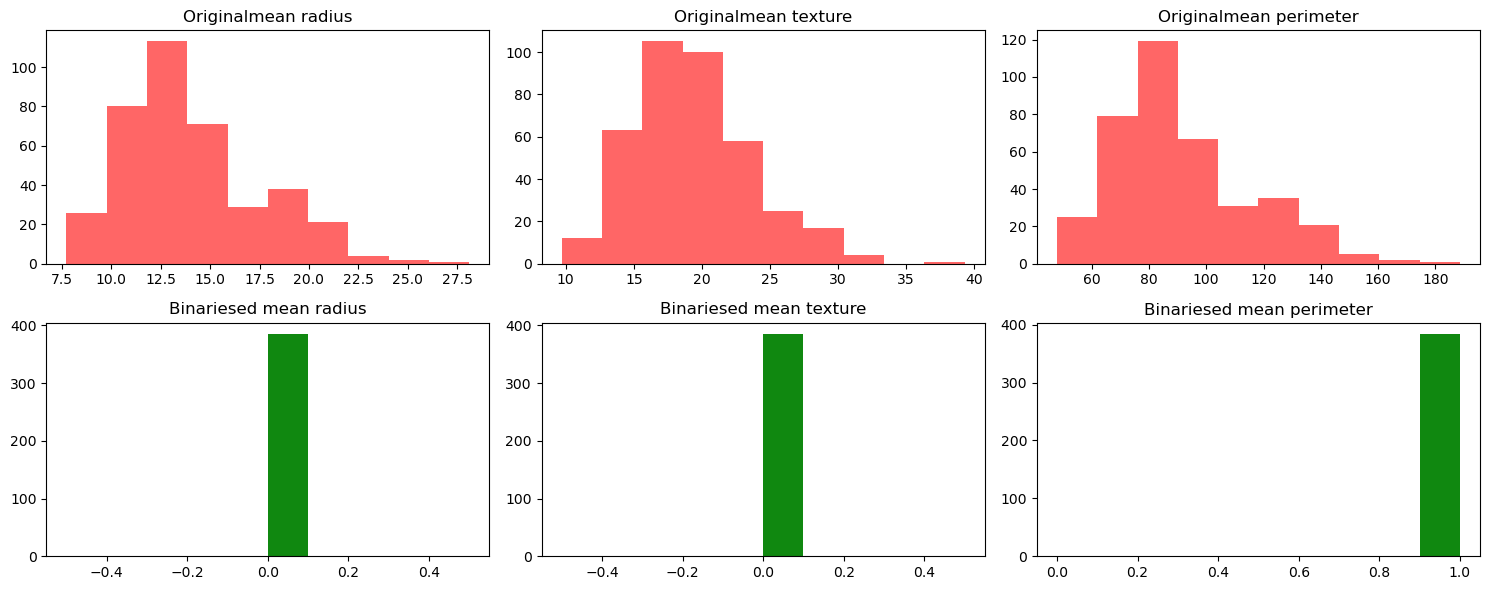

In [5]:
fig ,axes = plt.subplots(2,3 ,figsize =(15,6))
for i, col in enumerate(df.columns):
    axes[0,i].hist(df[col],alpha=0.6,bins =10,color = "red")
    axes[0,i].set_title(f"Original{col}")
    for i, col in enumerate(df.columns):
      axes[1, i].hist(df_binariesed[col], alpha=0.6, bins=10, color="green")
      axes[1, i].set_title(f"Binariesed {col}")
plt.tight_layout()
plt.show()


In [6]:
df =  pd.read_csv("sample_dataset.csv").iloc[:,0:3].dropna()
df

,mean radius,mean texture,mean perimeter
1,20.57,17.77,132.90
2,19.69,21.25,130.00
3,11.42,20.38,77.58
5,12.45,15.70,82.57
7,13.71,20.83,90.20
...,...,...,...
562,15.22,30.62,103.40
563,20.92,25.09,143.00
564,21.56,22.39,142.00
566,16.60,28.08,108.30


In [7]:
transform = FunctionTransformer(np.log1p, validate= True)
df_transformd = pd.DataFrame(transform.fit_transform(df),columns= df.columns)
df_transformd

,mean radius,mean texture,mean perimeter
0,3.071303,2.932260,4.897093
1,3.029650,3.102342,4.875197
2,2.519308,3.062456,4.364117
3,2.598979,2.815409,4.425685
4,2.688528,3.083285,4.513055
...,...,...,...
380,2.786245,3.453790,4.648230
381,3.087399,3.261552,4.969813
382,3.116178,3.152309,4.962845
383,2.867899,3.370051,4.694096


In [8]:
transform = FunctionTransformer(lambda x : x*3)
df_transformd = pd.DataFrame(transform.fit_transform(df),columns= df.columns)
df_transformd

,mean radius,mean texture,mean perimeter
1,61.71,53.31,398.70
2,59.07,63.75,390.00
3,34.26,61.14,232.74
5,37.35,47.10,247.71
7,41.13,62.49,270.60
...,...,...,...
562,45.66,91.86,310.20
563,62.76,75.27,429.00
564,64.68,67.17,426.00
566,49.80,84.24,324.90


In [9]:
transform = FunctionTransformer(lambda x, a : x*a, kw_args = {'a' : 4} )
df_transformd = pd.DataFrame(transform.fit_transform(df),columns= df.columns)
df_transformd

,mean radius,mean texture,mean perimeter
1,82.28,71.08,531.60
2,78.76,85.00,520.00
3,45.68,81.52,310.32
5,49.80,62.80,330.28
7,54.84,83.32,360.80
...,...,...,...
562,60.88,122.48,413.60
563,83.68,100.36,572.00
564,86.24,89.56,568.00
566,66.40,112.32,433.20
